In [3]:
import os, random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt

# -------------------- reproducibility --------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    ws = torch.initial_seed() % 2**32
    np.random.seed(ws)
    random.seed(ws)

# -------------------- data --------------------
def load_data(data_dir: str):
    d = Path(data_dir)
    X_train = np.loadtxt(d / "X_train.txt", dtype=np.float32)
    X_test  = np.loadtxt(d / "X_test.txt", dtype=np.float32)
    y_train = np.loadtxt(d / "y_train.txt", dtype=np.int64)
    y_test  = np.loadtxt(d / "y_test.txt", dtype=np.int64)

    # common: labels 1..6
    if y_train.min() == 1:
        y_train -= 1
        y_test -= 1
    return X_train, y_train, X_test, y_test

def stratified_split(X, y, val_frac=0.2, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, val_idx = [], []
    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        n_val = int(round(len(idx) * val_frac))
        val_idx.extend(idx[:n_val].tolist())
        train_idx.extend(idx[n_val:].tolist())
    rng.shuffle(train_idx); rng.shuffle(val_idx)
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx]

def standardize_train_only(X_tr, X_val, X_test):
    mu = X_tr.mean(axis=0, keepdims=True)
    sig = X_tr.std(axis=0, keepdims=True) + 1e-8
    return (X_tr-mu)/sig, (X_val-mu)/sig, (X_test-mu)/sig

# -------------------- built-in MLP (nn.Sequential) --------------------
def build_mlp(in_dim, num_classes, dropout=0.0):
    # Big MLP: 1024-1024-512
    layers = [
        nn.Linear(in_dim, 1024), nn.ReLU(inplace=True),
        nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
        nn.Linear(1024, 1024), nn.ReLU(inplace=True),
        nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
        nn.Linear(1024, 512), nn.ReLU(inplace=True),
        nn.Dropout(dropout) if dropout > 0 else nn.Identity(),
        nn.Linear(512, num_classes),
    ]
    return nn.Sequential(*layers)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ce = nn.CrossEntropyLoss()
    tot_loss, tot_correct, n = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = ce(logits, yb)
        tot_loss += float(loss.item()) * xb.size(0)
        tot_correct += int((logits.argmax(1) == yb).sum().item())
        n += xb.size(0)
    return tot_loss / max(n,1), tot_correct / max(n,1)

def train(
    run_name,
    model,
    train_loader,
    val_loader,
    device,
    epochs=200,
    lr=1e-3,
    weight_decay=0.0,
    use_scheduler=False,
    early_stop_patience=None,
):
    model.to(device)
    ce = nn.CrossEntropyLoss()

    # built-in optimizer (AdamW supports weight_decay cleanly)
    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    # built-in scheduler
    sched = None
    if use_scheduler:
        sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optim, mode="min", factor=0.5, patience=3
        )

    hist = {"train_loss": [], "val_loss": [], "val_acc": [], "lr": []}

    best_val_loss = float("inf")
    best_epoch = -1
    best_state = None
    bad = 0

    for epoch in range(1, epochs + 1):
        model.train()
        tot, n = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optim.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = ce(logits, yb)
            loss.backward()
            optim.step()
            tot += float(loss.item()) * xb.size(0)
            n += xb.size(0)

        train_loss = tot / max(n,1)
        val_loss, val_acc = evaluate(model, val_loader, device)

        if sched is not None:
            sched.step(val_loss)

        cur_lr = optim.param_groups[0]["lr"]
        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(val_acc)
        hist["lr"].append(cur_lr)

        print(f"[{run_name}] ep {epoch:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={cur_lr:.2e}")

        # early stopping (optional)
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if early_stop_patience is not None and bad >= early_stop_patience:
                print(f"[{run_name}] Early stop at epoch {epoch} (best epoch {best_epoch})")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    summary = {
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "best_val_acc": float(np.max(hist["val_acc"])) if hist["val_acc"] else None,
        "final_epoch": len(hist["train_loss"]),
        "final_val_loss": hist["val_loss"][-1],
        "final_val_acc": hist["val_acc"][-1],
        "history": hist,
    }
    return model, summary

def plot_curves(run_name, hist, out_dir="outputs"):
    out = Path(out_dir); out.mkdir(exist_ok=True)
    # loss
    plt.figure()
    plt.plot(hist["train_loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"{run_name} loss"); plt.legend()
    plt.tight_layout(); plt.savefig(out / f"{run_name}_loss.png", dpi=200); plt.plot()
    plt.close()
    # metric
    plt.figure()
    plt.plot(hist["val_acc"], label="val_acc")
    plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title(f"{run_name} val_acc"); plt.legend()
    plt.tight_layout(); plt.savefig(out / f"{run_name}_valacc.png", dpi=200); plt.plot()
    plt.close()
    # lr
    plt.figure()
    plt.plot(hist["lr"], label="lr")
    plt.xlabel("epoch"); plt.ylabel("lr"); plt.title(f"{run_name} lr"); plt.legend()
    plt.tight_layout(); plt.savefig(out / f"{run_name}_lr.png", dpi=200); plt.plot()
    plt.close()

seed = 42
seed_everything(seed)

DATA_DIR = "./sample_data/"  # change if needed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[LOG] seed={seed} device={device}")

X_train, y_train, X_test, y_test = load_data(DATA_DIR)
X_tr, y_tr, X_val, y_val = stratified_split(X_train, y_train, val_frac=0.2, seed=seed)
X_tr, X_val, X_test = standardize_train_only(X_tr, X_val, X_test)

num_classes = int(y_train.max() + 1)
in_dim = X_tr.shape[1]

# torch tensors
X_tr_t = torch.from_numpy(X_tr); y_tr_t = torch.from_numpy(y_tr)
X_val_t = torch.from_numpy(X_val); y_val_t = torch.from_numpy(y_val)
X_test_t = torch.from_numpy(X_test); y_test_t = torch.from_numpy(y_test)

g = torch.Generator().manual_seed(seed)
train_loader = DataLoader(
    TensorDataset(X_tr_t, y_tr_t),
    batch_size=128,
    shuffle=True,
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=g,
)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=512, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=512, shuffle=False)

# ---------------- BEFORE: induce overfitting ----------------
before_model = build_mlp(in_dim, num_classes, dropout=0.0)  # no dropout
before_model, before = train(
    "before_overfit",
    before_model,
    train_loader,
    val_loader,
    device,
    epochs=20,
    lr=1e-3,
    weight_decay=0.0,       # no weight decay
    use_scheduler=False,    # no scheduler
    early_stop_patience=None,
)
test_loss_b, test_acc_b = evaluate(before_model, test_loader, device)
before["test_acc"] = test_acc_b; before["test_loss"] = test_loss_b
plot_curves("before_overfit", before["history"], out_dir="outputs")

# ---------------- AFTER: fix using >=2 methods ----------------
# Methods used here: dropout + weight_decay + early_stopping + LR scheduling
after_model = build_mlp(in_dim, num_classes, dropout=0.5)
after_model, after = train(
    "after_fixed",
    after_model,
    train_loader,
    val_loader,
    device,
    epochs=20,
    lr=1e-3,
    weight_decay=1e-4,      # weight decay
    use_scheduler=True,     # LR scheduling
    early_stop_patience=10, # early stopping
)
test_loss_a, test_acc_a = evaluate(after_model, test_loader, device)
after["test_acc"] = test_acc_a; after["test_loss"] = test_loss_a
plot_curves("after_fixed", after["history"], out_dir="outputs")

# ---------------- report numbers ----------------
def fmt(s):
    return (f"best_epoch={s['best_epoch']}, best_val_loss={s['best_val_loss']:.4f}, "
            f"best_val_acc={s['best_val_acc']:.4f}, final_epoch={s['final_epoch']}, "
            f"final_val_loss={s['final_val_loss']:.4f}, final_val_acc={s['final_val_acc']:.4f}, "
            f"test_acc={s['test_acc']:.4f}")

print("\n===== BEFORE (overfit) =====")
print(fmt(before))
print("\n===== AFTER (fixed) =====")
print(fmt(after))
print("\nSaved plots in ./outputs/:")
print("  before_overfit_loss.png, before_overfit_valacc.png")
print("  after_fixed_loss.png, after_fixed_valacc.png")
print("  (and lr plots)")


[LOG] seed=42 device=cpu
[before_overfit] ep 001 | train_loss=0.4007 | val_loss=0.1608 | val_acc=0.9435 | lr=1.00e-03
[before_overfit] ep 002 | train_loss=0.0923 | val_loss=0.0932 | val_acc=0.9626 | lr=1.00e-03
[before_overfit] ep 003 | train_loss=0.0559 | val_loss=0.1291 | val_acc=0.9565 | lr=1.00e-03
[before_overfit] ep 004 | train_loss=0.0705 | val_loss=0.0882 | val_acc=0.9646 | lr=1.00e-03
[before_overfit] ep 005 | train_loss=0.0439 | val_loss=0.0749 | val_acc=0.9769 | lr=1.00e-03
[before_overfit] ep 006 | train_loss=0.0485 | val_loss=0.1394 | val_acc=0.9578 | lr=1.00e-03
[before_overfit] ep 007 | train_loss=0.0389 | val_loss=0.1006 | val_acc=0.9660 | lr=1.00e-03
[before_overfit] ep 008 | train_loss=0.0224 | val_loss=0.0882 | val_acc=0.9667 | lr=1.00e-03
[before_overfit] ep 009 | train_loss=0.0265 | val_loss=0.0788 | val_acc=0.9769 | lr=1.00e-03
[before_overfit] ep 010 | train_loss=0.0242 | val_loss=0.0835 | val_acc=0.9776 | lr=1.00e-03
[before_overfit] ep 011 | train_loss=0.0191 |

[]

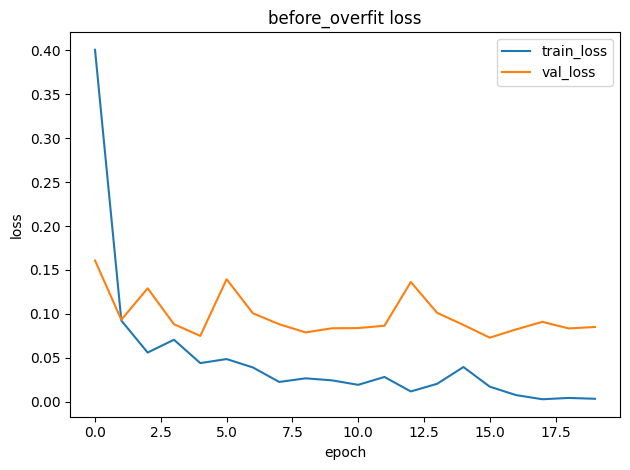

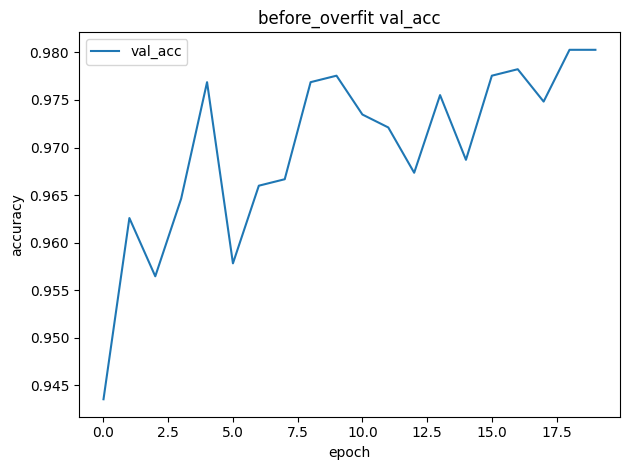

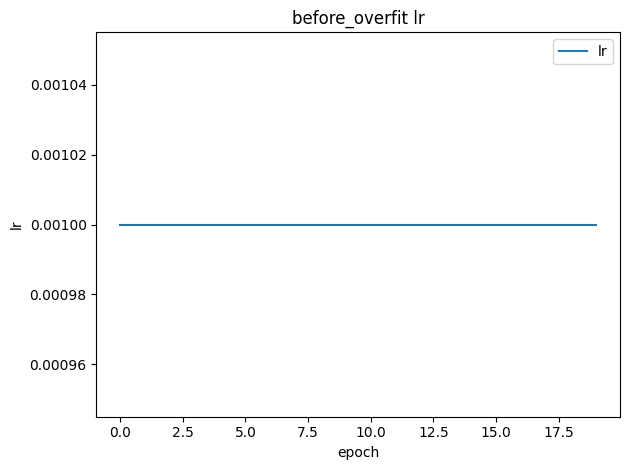

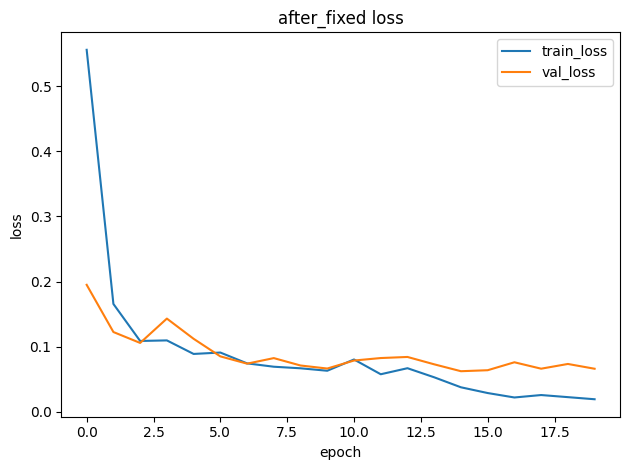

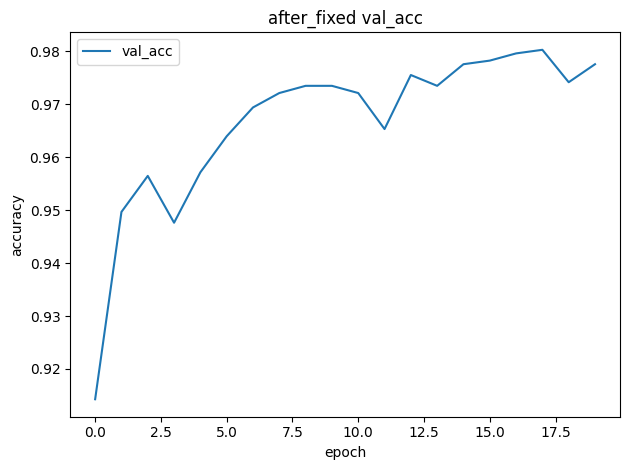

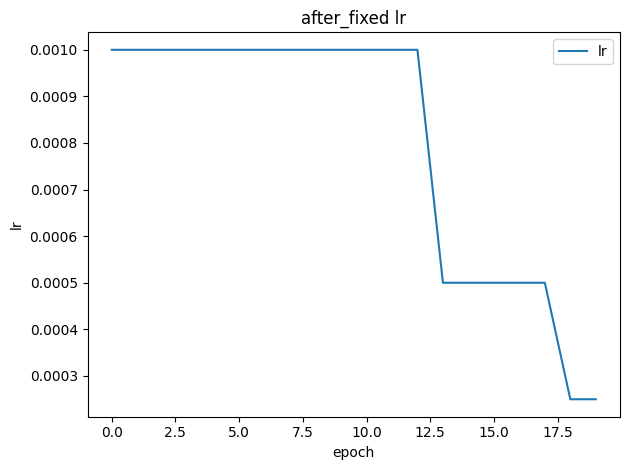

In [4]:
hist = before["history"]
run_name = "before_overfit"
# loss
plt.figure()
plt.plot(hist["train_loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"{run_name} loss"); plt.legend()
plt.tight_layout(); plt.plot()
# metric
plt.figure()
plt.plot(hist["val_acc"], label="val_acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title(f"{run_name} val_acc"); plt.legend()
plt.tight_layout(); plt.plot()
# lr
plt.figure()
plt.plot(hist["lr"], label="lr")
plt.xlabel("epoch"); plt.ylabel("lr"); plt.title(f"{run_name} lr"); plt.legend()
plt.tight_layout(); plt.plot()

hist = after["history"]
run_name = "after_fixed"
# loss
plt.figure()
plt.plot(hist["train_loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title(f"{run_name} loss"); plt.legend()
plt.tight_layout(); plt.plot()
# metric
plt.figure()
plt.plot(hist["val_acc"], label="val_acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.title(f"{run_name} val_acc"); plt.legend()
plt.tight_layout(); plt.plot()
# lr
plt.figure()
plt.plot(hist["lr"], label="lr")
plt.xlabel("epoch"); plt.ylabel("lr"); plt.title(f"{run_name} lr"); plt.legend()
plt.tight_layout(); plt.plot()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [5]:
#9. Instability debug
def train_debug(run_name, model, train_loader, device, epochs=10, lr=1e-3, max_grad_norm=None):
    model.to(device)
    ce = nn.CrossEntropyLoss()
    optim = torch.optim.AdamW(model.parameters(), lr=lr)

    print(f"\n>>> Starting Run: {run_name} (LR={lr}, Clip={max_grad_norm})")

    for epoch in range(1, epochs + 1):
        model.train()
        tot_loss = 0.0
        n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optim.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = ce(logits, yb)

            if torch.isnan(loss):
                print(f"[FAIL] Epoch {epoch}: NaN detected in loss!")
                return None # Exit early on failure

            loss.backward()

            if max_grad_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optim.step()
            tot_loss += loss.item() * xb.size(0)
            n += xb.size(0)

        print(f"Epoch {epoch:02d} | Loss: {tot_loss/n:.4f}")
    return model

#Trigger NaNs from high LR
print("SCENARIO 1: INTENTIONAL INSTABILITY")
model_bad = build_mlp(in_dim, num_classes)
train_debug("High_LR_Failure", model_bad, train_loader, device, lr=100.0)

#Fix using Gradient Clipping & Lower Learning Rate
#Lower LR (1e-3)
#Gradient Clipping (max_norm=1.0)
print("\nSCENARIO 2: FIXED STABILITY")
model_good = build_mlp(in_dim, num_classes)
train_debug("Stable_Training", model_good, train_loader, device,
            lr=1e-3,
            max_grad_norm=1.0)

SCENARIO 1: INTENTIONAL INSTABILITY

>>> Starting Run: High_LR_Failure (LR=100.0, Clip=None)
Epoch 01 | Loss: 2020051755105142.7500
Epoch 02 | Loss: 43.9561
Epoch 03 | Loss: 120.3512
Epoch 04 | Loss: 9.2806
Epoch 05 | Loss: 8.4738
Epoch 06 | Loss: 9.1987
Epoch 07 | Loss: 9.0140
Epoch 08 | Loss: 10.4067
Epoch 09 | Loss: 8.9881
Epoch 10 | Loss: 9.6320

SCENARIO 2: FIXED STABILITY

>>> Starting Run: Stable_Training (LR=0.001, Clip=1.0)
Epoch 01 | Loss: 0.4427
Epoch 02 | Loss: 0.1590
Epoch 03 | Loss: 0.0900
Epoch 04 | Loss: 0.0633
Epoch 05 | Loss: 0.0534
Epoch 06 | Loss: 0.0490
Epoch 07 | Loss: 0.0385
Epoch 08 | Loss: 0.0302
Epoch 09 | Loss: 0.0237
Epoch 10 | Loss: 0.0428


Sequential(
  (0): Linear(in_features=561, out_features=1024, bias=True)
  (1): ReLU(inplace=True)
  (2): Identity()
  (3): Linear(in_features=1024, out_features=1024, bias=True)
  (4): ReLU(inplace=True)
  (5): Identity()
  (6): Linear(in_features=1024, out_features=512, bias=True)
  (7): ReLU(inplace=True)
  (8): Identity()
  (9): Linear(in_features=512, out_features=6, bias=True)
)